# Grupo 10

# INTEGRANTES


*   Roni Edwin Oyardo Acuña
*   Ronald Chipana Wariste
*   Nancy Illanes Castillo
*   Cecilia Elsa Choque Berdeja





#  Sprint 1 Forecast de Ingresos Mensuales | Olist E-Commerce

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Objetivo:** Predecir los ingresos mensuales globales del e-commerce  
**Target:** `monthly_revenue`  
**Tipo de Modelo:** Series Temporales  
**Métricas:** RMSE, MAPE  



## Etapas del Sprint 1
1. Setup y carga de datos
2. Definición del problema de negocio
3. Formulación de hipótesis
4. Construcción de Master Table (60 features)
5. EDA Exploratorio
6. Baseline del modelo
7. Métricas técnicas y de negocio
8. Conclusiones y hallazgos

# 1. Setup Importaciones y Configuración

In [ ]:
# Instalación de librerías necesarias
!pip install -q kaggle plotly statsmodels prophet scikit-learn openpyxl xlsxwriter
print(' Instalación completada')

 Instalación completada


In [ ]:
# ─── Librerías estándar
import os
import warnings
import zipfile
warnings.filterwarnings('ignore')

# ─── Datos
import numpy as np
import pandas as pd

# ─── Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Series Temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ─── Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# ─── Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(' Librerías importadas correctamente')
print(f'   Pandas: {pd.__version__} | NumPy: {np.__version__}')

 Librerías importadas correctamente
   Pandas: 2.2.2 | NumPy: 2.0.2


# 2. Carga de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Opción B: Desde Google Drive (si ya tienes los CSV descargados)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/olist_data/'  # Ajustar ruta

# ── Descarga del dataset desde Kaggle
!kaggle datasets download -d olistbr/brazilian-ecommerce --unzip -p /content/olist_data/
print(' Dataset descargado')

DATA_PATH = '/content/drive/MyDrive/MAESTRIA/Modulo13/dev/data/'
print('\n Archivos disponibles:')
for f in sorted(os.listdir(DATA_PATH)):
    size_mb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1e6
    print(f'   {f:55s} {size_mb:.2f} MB')

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 47.5MB/s]

 Dataset descargado

 Archivos disponibles:
   olist_customers_dataset.csv                             9.03 MB
   olist_geolocation_dataset.csv                           61.27 MB
   olist_order_items_dataset.csv                           15.44 MB
   olist_order_payments_dataset.csv                        5.78 MB
   olist_order_reviews_dataset.csv                         14.45 MB
   olist_orders_dataset.csv                                17.65 MB
   olist_products_dataset.csv                              2.38 MB
   olist_sellers_dataset.csv                               0.17 MB
   output                                                  0.00 MB
   product_category_name_translation.csv                   0.00 MB


# 3. Carga y Vista Previa de los Datasets

In [ ]:
# ─── Carga de todos los datasets
df_orders         = pd.read_csv(f'{DATA_PATH}olist_orders_dataset.csv')
df_order_items    = pd.read_csv(f'{DATA_PATH}olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(f'{DATA_PATH}olist_order_payments_dataset.csv')
df_order_reviews  = pd.read_csv(f'{DATA_PATH}olist_order_reviews_dataset.csv')
df_customers      = pd.read_csv(f'{DATA_PATH}olist_customers_dataset.csv')
df_products       = pd.read_csv(f'{DATA_PATH}olist_products_dataset.csv')
df_sellers        = pd.read_csv(f'{DATA_PATH}olist_sellers_dataset.csv')
df_category_trans = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')
df_geolocation    = pd.read_csv(f'{DATA_PATH}olist_geolocation_dataset.csv')

# ─── Resumen de datasets
datasets = {
    'orders':         df_orders,
    'order_items':    df_order_items,
    'order_payments': df_order_payments,
    'order_reviews':  df_order_reviews,
    'customers':      df_customers,
    'products':       df_products,
    'sellers':        df_sellers,
    'category_trans': df_category_trans,
    'geolocation':    df_geolocation,
}

print(' RESUMEN DE DATASETS')
print('='*55)
for name, df in datasets.items():
    print(f'{name:20s}: {df.shape[0]:>8,} filas  x  {df.shape[1]:>3} columnas')

 RESUMEN DE DATASETS
orders              :   99,441 filas  x    8 columnas
order_items         :  112,650 filas  x    7 columnas
order_payments      :  103,886 filas  x    5 columnas
order_reviews       :   99,224 filas  x    7 columnas
customers           :   99,441 filas  x    5 columnas
products            :   32,951 filas  x    9 columnas
sellers             :    3,095 filas  x    4 columnas
category_trans      :       71 filas  x    2 columnas
geolocation         : 1,000,163 filas  x    5 columnas


In [ ]:
# ─── Conversión de fechas
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

df_order_items['shipping_limit_date'] = pd.to_datetime(
    df_order_items['shipping_limit_date'], errors='coerce'
)

print(' Fechas convertidas')
print(f'   Rango temporal: {df_orders["order_purchase_timestamp"].min().date()} '
      f'→ {df_orders["order_purchase_timestamp"].max().date()}')
print(f'   Total meses disponibles: '
      f'{df_orders["order_purchase_timestamp"].dt.to_period("M").nunique()}')

 Fechas convertidas
   Rango temporal: 2016-09-04 → 2018-10-17
   Total meses disponibles: 25


# 4. Definición del Problema de Negocio
# 4.1 Contexto Estratégico

In [ ]:
problem_definition = """
╔══════════════════════════════════════════════════════════════════════════╗
║           DEFINICIÓN DEL PROBLEMA DE NEGOCIO - SPRINT 1                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  CONTEXTO:                                                               ║
║  Olist es un marketplace brasileño que conecta pequeños comerciantes     ║
║  con los principales e-commerces del país.                               ║
║                                                                          ║
║  PROBLEMA DE NEGOCIO:                                                    ║
║  La incapacidad de predecir los ingresos mensuales con precisión         ║
║  genera ineficiencias en la planificación de inventario, recursos        ║
║  humanos y estrategias de marketing.                                     ║
║                                                                          ║
║  OBJETIVO DEL MODELO:                                                    ║
║  Desarrollar un modelo de series temporales que prediga el               ║
║  monthly_revenue con un horizonte de 3 meses, con MAPE < 10%.            ║
║                                                                          ║
║  IMPACTO ESPERADO:                                                       ║
║  • Optimizar la planificación de presupuesto trimestral                  ║
║  • Identificar estacionalidades y picos de demanda                       ║
║  • Anticipar caídas en ingresos para acciones correctivas                ║
║  • Apoyar decisiones de expansión de categorías                          ║
║                                                                          ║
║  TARGET VARIABLE: monthly_revenue (suma de payment_value por mes)        ║
║  HORIZONTE:       3 meses                                                ║
║  GRANULARIDAD:    Mensual                                                ║
║  MÉTRICAS:        RMSE, MAPE (objetivo: MAPE < 10%)                      ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(problem_definition)


╔══════════════════════════════════════════════════════════════════════════╗
║           DEFINICIÓN DEL PROBLEMA DE NEGOCIO - SPRINT 1                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  CONTEXTO:                                                               ║
║  Olist es un marketplace brasileño que conecta pequeños comerciantes     ║
║  con los principales e-commerces del país.                               ║
║                                                                          ║
║  PROBLEMA DE NEGOCIO:                                                    ║
║  La incapacidad de predecir los ingresos mensuales con precisión         ║
║  genera ineficiencias en la planificación de inventario, recursos        ║
║  humanos y estrategias de marketing.                                     ║
║                                                                          ║

# 4.2 Hipótesis de Negocio

In [ ]:
hypotheses = {
    'H1': {
        'descripcion': 'Estacionalidad anual fuerte (picos en nov-dic por Black Friday y Navidad)',
        'variable_clave': 'month, order_purchase_timestamp',
        'validacion': 'Descomposición de serie temporal + análisis por mes'
    },
    'H2': {
        'descripcion': 'El número de pedidos tiene correlación positiva con los ingresos mensuales',
        'variable_clave': 'monthly_orders vs monthly_revenue',
        'validacion': 'Correlación de Pearson / Spearman'
    },
    'H3': {
        'descripcion': 'Ciertas categorías de productos impulsan desproporcionadamente los ingresos',
        'variable_clave': 'product_category_name_english',
        'validacion': 'Análisis de Pareto por categoría'
    },
    'H4': {
        'descripcion': 'El tiempo de entrega promedio impacta negativamente en la satisfacción y retención',
        'variable_clave': 'delivery_delay_days vs review_score',
        'validacion': 'Correlación + análisis de cuartiles'
    },
    'H5': {
        'descripcion': 'La tasa de recompra mensual tiene correlación con el crecimiento de ingresos',
        'variable_clave': 'repeat_customer_rate vs revenue_growth',
        'validacion': 'Análisis de clientes recurrentes por cohorte mensual'
    },
    'H6': {
        'descripcion': 'Los métodos de pago preferidos varían por mes y afectan el ticket promedio',
        'variable_clave': 'payment_type vs avg_payment_value',
        'validacion': 'Análisis descriptivo por tipo de pago'
    },
}

print(' HIPÓTESIS FORMULADAS PARA VALIDACIÓN')
print('='*70)
for key, h in hypotheses.items():
    print(f'\n[{key}] {h["descripcion"]}')
    print(f'      Variable clave : {h["variable_clave"]}')
    print(f'      Validación     : {h["validacion"]}')

 HIPÓTESIS FORMULADAS PARA VALIDACIÓN

[H1] Estacionalidad anual fuerte (picos en nov-dic por Black Friday y Navidad)
      Variable clave : month, order_purchase_timestamp
      Validación     : Descomposición de serie temporal + análisis por mes

[H2] El número de pedidos tiene correlación positiva con los ingresos mensuales
      Variable clave : monthly_orders vs monthly_revenue
      Validación     : Correlación de Pearson / Spearman

[H3] Ciertas categorías de productos impulsan desproporcionadamente los ingresos
      Variable clave : product_category_name_english
      Validación     : Análisis de Pareto por categoría

[H4] El tiempo de entrega promedio impacta negativamente en la satisfacción y retención
      Variable clave : delivery_delay_days vs review_score
      Validación     : Correlación + análisis de cuartiles

[H5] La tasa de recompra mensual tiene correlación con el crecimiento de ingresos
      Variable clave : repeat_customer_rate vs revenue_growth
      Validaci

# 5. Construcción de la Master Table
# 5.1 Join de tablas base

In [ ]:
# ─── Traducción de categorías al inglés
df_products = df_products.merge(df_category_trans, on='product_category_name', how='left')

# ─── Merge principal: orders + items + payments + reviews
df_master = (
    df_orders
    .merge(df_order_items,    on='order_id',   how='left')
    .merge(df_order_payments, on='order_id',   how='left')
    .merge(df_order_reviews[['order_id', 'review_score', 'review_comment_title']],
           on='order_id', how='left')
    .merge(df_customers[['customer_id', 'customer_unique_id',
                          'customer_city', 'customer_state']],
           on='customer_id', how='left')
    .merge(df_products[['product_id', 'product_category_name_english',
                         'product_weight_g', 'product_length_cm',
                         'product_height_cm', 'product_width_cm']],
           on='product_id', how='left')
    .merge(df_sellers[['seller_id', 'seller_city', 'seller_state']],
           on='seller_id', how='left')
)

print(f' Master Table creada: {df_master.shape[0]:,} filas x {df_master.shape[1]} columnas')
df_master.head(3)

 Master Table creada: 119,143 filas x 30 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,customer_unique_id,customer_city,customer_state,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.00,credit_card,1.00,18.12,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.00,voucher,1.00,2.00,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.00,voucher,1.00,18.59,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP


# 5.2 Feature Engineering – 60 Variables

In [ ]:
# ─── BLOQUE 1: Features temporales
df_master['order_year']           = df_master['order_purchase_timestamp'].dt.year
df_master['order_month']          = df_master['order_purchase_timestamp'].dt.month
df_master['order_quarter']        = df_master['order_purchase_timestamp'].dt.quarter
df_master['order_week']           = df_master['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
df_master['order_dayofweek']      = df_master['order_purchase_timestamp'].dt.dayofweek
df_master['order_dayofmonth']     = df_master['order_purchase_timestamp'].dt.day
df_master['order_hour']           = df_master['order_purchase_timestamp'].dt.hour
df_master['is_weekend']           = df_master['order_dayofweek'].isin([5, 6]).astype(int)
df_master['is_end_of_month']      = (df_master['order_dayofmonth'] >= 25).astype(int)
df_master['year_month']           = df_master['order_purchase_timestamp'].dt.to_period('M')

# ─── BLOQUE 2: Features de entrega
df_master['delivery_days_actual'] = (
    df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']
).dt.days

df_master['delivery_days_estimated'] = (
    df_master['order_estimated_delivery_date'] - df_master['order_purchase_timestamp']
).dt.days

df_master['delivery_delay_days'] = (
    df_master['delivery_days_actual'] - df_master['delivery_days_estimated']
)

df_master['is_late_delivery']     = (df_master['delivery_delay_days'] > 0).astype(int)
df_master['carrier_days']         = (
    df_master['order_delivered_carrier_date'] - df_master['order_purchase_timestamp']
).dt.days

# ─── BLOQUE 3: Features de pago
df_master['is_credit_card']       = (df_master['payment_type'] == 'credit_card').astype(int)
df_master['is_boleto']            = (df_master['payment_type'] == 'boleto').astype(int)
df_master['is_voucher']           = (df_master['payment_type'] == 'voucher').astype(int)
df_master['is_debit_card']        = (df_master['payment_type'] == 'debit_card').astype(int)
df_master['payment_installments_flag'] = (df_master['payment_installments'] > 1).astype(int)

# ─── BLOQUE 4: Features de producto
df_master['product_volume_cm3']   = (
    df_master['product_length_cm'] *
    df_master['product_height_cm'] *
    df_master['product_width_cm']
)
df_master['freight_ratio']        = (
    df_master['freight_value'] /
    (df_master['price'] + df_master['freight_value'] + 1e-9)
)

# ─── BLOQUE 5: Flag orden entregada
df_master['is_delivered']         = (df_master['order_status'] == 'delivered').astype(int)
df_master['is_canceled']          = (df_master['order_status'] == 'canceled').astype(int)

print(f' Features de transacción creadas: {df_master.shape[1]} columnas totales')

 Features de transacción creadas: 54 columnas totales


# 5.3 Construcción de la Serie Temporal Mensual TARGET

In [ ]:
# ─── Filtrar solo órdenes entregadas con pagos válidos
df_valid = df_master[
    (df_master['order_status'] == 'delivered') &
    (df_master['payment_value'].notna()) &
    (df_master['payment_value'] > 0)
].copy()

print(f' Órdenes válidas (delivered + payment > 0): {df_valid["order_id"].nunique():,}')

# ─── Construir tabla mensual
monthly_agg = df_valid.groupby('year_month').agg(
    monthly_revenue           = ('payment_value',          'sum'),
    monthly_orders            = ('order_id',               'nunique'),
    monthly_customers         = ('customer_unique_id',     'nunique'),
    monthly_items             = ('order_item_id',          'count'),
    avg_ticket                = ('payment_value',          'mean'),
    median_ticket             = ('payment_value',          'median'),
    avg_review_score          = ('review_score',           'mean'),
    avg_delivery_days         = ('delivery_days_actual',   'mean'),
    avg_delay_days            = ('delivery_delay_days',    'mean'),
    pct_late_delivery         = ('is_late_delivery',       'mean'),
    avg_freight               = ('freight_value',          'mean'),
    avg_price                 = ('price',                  'mean'),
    total_freight             = ('freight_value',          'sum'),
    pct_credit_card           = ('is_credit_card',         'mean'),
    pct_boleto                = ('is_boleto',              'mean'),
    pct_installments          = ('payment_installments_flag', 'mean'),
    avg_installments          = ('payment_installments',   'mean'),
    unique_categories         = ('product_category_name_english', 'nunique'),
    unique_sellers            = ('seller_id',              'nunique'),
    unique_states             = ('customer_state',         'nunique'),
).reset_index()

# ─── Convertir year_month a datetime
monthly_agg['ds'] = monthly_agg['year_month'].dt.to_timestamp()
monthly_agg = monthly_agg.sort_values('ds').reset_index(drop=True)

# ─── Eliminar primer y último mes (incompletos)
monthly_agg = monthly_agg.iloc[1:-1].reset_index(drop=True)

print(f'\n Serie temporal mensual: {len(monthly_agg)} meses')
print(f'   Desde: {monthly_agg["ds"].min().strftime("%B %Y")}')
print(f'   Hasta: {monthly_agg["ds"].max().strftime("%B %Y")}')
monthly_agg[['ds', 'monthly_revenue', 'monthly_orders', 'avg_ticket']].head(10)

 Órdenes válidas (delivered + payment > 0): 96,477

 Serie temporal mensual: 20 meses
   Desde: December 2016
   Hasta: July 2018


,ds,monthly_revenue,monthly_orders,avg_ticket
0,2016-12-01,19.62,1,19.62
1,2017-01-01,"178,282.10",750,181.74
2,2017-02-01,"327,928.86",1653,166.21
3,2017-03-01,"508,767.44",2546,164.22
4,2017-04-01,"457,050.31",2303,168.34
5,2017-05-01,"707,042.90",3546,164.16
6,2017-06-01,"590,223.90",3135,158.41
7,2017-07-01,"720,446.68",3872,151.01
8,2017-08-01,"850,611.08",4193,166.56
9,2017-09-01,"1,003,326.07",4150,199.07


# 5.4 Features de Lag y Rolling - para el modelo

In [ ]:
# ─── Lag features
for lag in [1, 2, 3, 6, 12]:
    monthly_agg[f'revenue_lag_{lag}']  = monthly_agg['monthly_revenue'].shift(lag)
    monthly_agg[f'orders_lag_{lag}']   = monthly_agg['monthly_orders'].shift(lag)

# ─── Rolling features
for window in [3, 6]:
    monthly_agg[f'revenue_rolling_mean_{window}'] = (
        monthly_agg['monthly_revenue'].shift(1).rolling(window).mean()
    )
    monthly_agg[f'revenue_rolling_std_{window}'] = (
        monthly_agg['monthly_revenue'].shift(1).rolling(window).std()
    )

# ─── Growth features
monthly_agg['revenue_mom_growth'] = monthly_agg['monthly_revenue'].pct_change(1)
monthly_agg['revenue_yoy_growth'] = monthly_agg['monthly_revenue'].pct_change(12)

# ─── Features temporales cíclicas
monthly_agg['month']        = monthly_agg['ds'].dt.month
monthly_agg['quarter']      = monthly_agg['ds'].dt.quarter
monthly_agg['month_sin']    = np.sin(2 * np.pi * monthly_agg['month'] / 12)
monthly_agg['month_cos']    = np.cos(2 * np.pi * monthly_agg['month'] / 12)
monthly_agg['is_q4']        = (monthly_agg['quarter'] == 4).astype(int)
monthly_agg['is_nov_dec']   = monthly_agg['month'].isin([11, 12]).astype(int)

print(f' Master Table mensual completada: {monthly_agg.shape[1]} features')
print('\n Lista de features generadas:')
for i, col in enumerate(monthly_agg.columns, 1):
    print(f'   {i:3}. {col}')

 Master Table mensual completada: 44 features

 Lista de features generadas:
     1. year_month
     2. monthly_revenue
     3. monthly_orders
     4. monthly_customers
     5. monthly_items
     6. avg_ticket
     7. median_ticket
     8. avg_review_score
     9. avg_delivery_days
    10. avg_delay_days
    11. pct_late_delivery
    12. avg_freight
    13. avg_price
    14. total_freight
    15. pct_credit_card
    16. pct_boleto
    17. pct_installments
    18. avg_installments
    19. unique_categories
    20. unique_sellers
    21. unique_states
    22. ds
    23. revenue_lag_1
    24. orders_lag_1
    25. revenue_lag_2
    26. orders_lag_2
    27. revenue_lag_3
    28. orders_lag_3
    29. revenue_lag_6
    30. orders_lag_6
    31. revenue_lag_12
    32. orders_lag_12
    33. revenue_rolling_mean_3
    34. revenue_rolling_std_3
    35. revenue_rolling_mean_6
    36. revenue_rolling_std_6
    37. revenue_mom_growth
    38. revenue_yoy_growth
    39. month
    40. quarter
    41. mo

## 6. EDA Exploratorio

### 6.1 Análisis de Missing Values y Calidad de Datos

In [ ]:
print(' ANÁLISIS DE CALIDAD DE DATOS – MASTER TABLE MENSUAL')
print('='*60)

null_analysis = pd.DataFrame({
    'null_count': monthly_agg.isnull().sum(),
    'null_pct':   (monthly_agg.isnull().mean() * 100).round(2)
}).query('null_count > 0').sort_values('null_pct', ascending=False)

if len(null_analysis) > 0:
    print(f'\n  Features con nulls (por diseño de lags):')
    print(null_analysis.to_string())
else:
    print('\n Sin missing values en features base')

print('\n Estadísticas descriptivas – variable target:')
print(monthly_agg['monthly_revenue'].describe().to_frame().T.to_string())

 ANÁLISIS DE CALIDAD DE DATOS – MASTER TABLE MENSUAL

  Features con nulls (por diseño de lags):
                        null_count  null_pct
orders_lag_12                   12     60.00
revenue_yoy_growth              12     60.00
revenue_lag_12                  12     60.00
revenue_lag_6                    6     30.00
revenue_rolling_mean_6           6     30.00
orders_lag_6                     6     30.00
revenue_rolling_std_6            6     30.00
revenue_lag_3                    3     15.00
orders_lag_3                     3     15.00
revenue_rolling_mean_3           3     15.00
revenue_rolling_std_3            3     15.00
revenue_lag_2                    2     10.00
orders_lag_2                     2     10.00
revenue_lag_1                    1      5.00
orders_lag_1                     1      5.00
revenue_mom_growth               1      5.00

 Estadísticas descriptivas – variable target:
                 count       mean        std   min        25%          50%          75%    

# 6.2 Serie Temporal de Ingresos Mensuales

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Ingresos Mensuales (BRL)',
        'Órdenes Mensuales',
        'Ticket Promedio Mensual (BRL)',
        'Crecimiento MoM de Ingresos (%)'
    ]
)

# Revenue
fig.add_trace(
    go.Scatter(x=monthly_agg['ds'], y=monthly_agg['monthly_revenue'],
               mode='lines+markers', name='Revenue',
               line=dict(color='#2196F3', width=2)),
    row=1, col=1
)

# Orders
fig.add_trace(
    go.Bar(x=monthly_agg['ds'], y=monthly_agg['monthly_orders'],
           name='Orders', marker_color='#4CAF50'),
    row=1, col=2
)

# Avg Ticket
fig.add_trace(
    go.Scatter(x=monthly_agg['ds'], y=monthly_agg['avg_ticket'],
               mode='lines+markers', name='Avg Ticket',
               line=dict(color='#FF9800', width=2)),
    row=2, col=1
)

# MoM Growth
colors_growth = ['#F44336' if v < 0 else '#4CAF50'
                 for v in monthly_agg['revenue_mom_growth'].fillna(0)]
fig.add_trace(
    go.Bar(x=monthly_agg['ds'],
           y=(monthly_agg['revenue_mom_growth'] * 100).round(2),
           name='MoM Growth', marker_color=colors_growth),
    row=2, col=2
)

fig.update_layout(
    height=600, title_text=' Dashboard de Serie Temporal – Olist Revenue',
    showlegend=False, title_font_size=16
)
fig.show()

### 6.3 Descomposición de la Serie Temporal

 Observaciones disponibles: 20 meses
 Método utilizado: STL (period=6, semestral — datos < 24 meses)


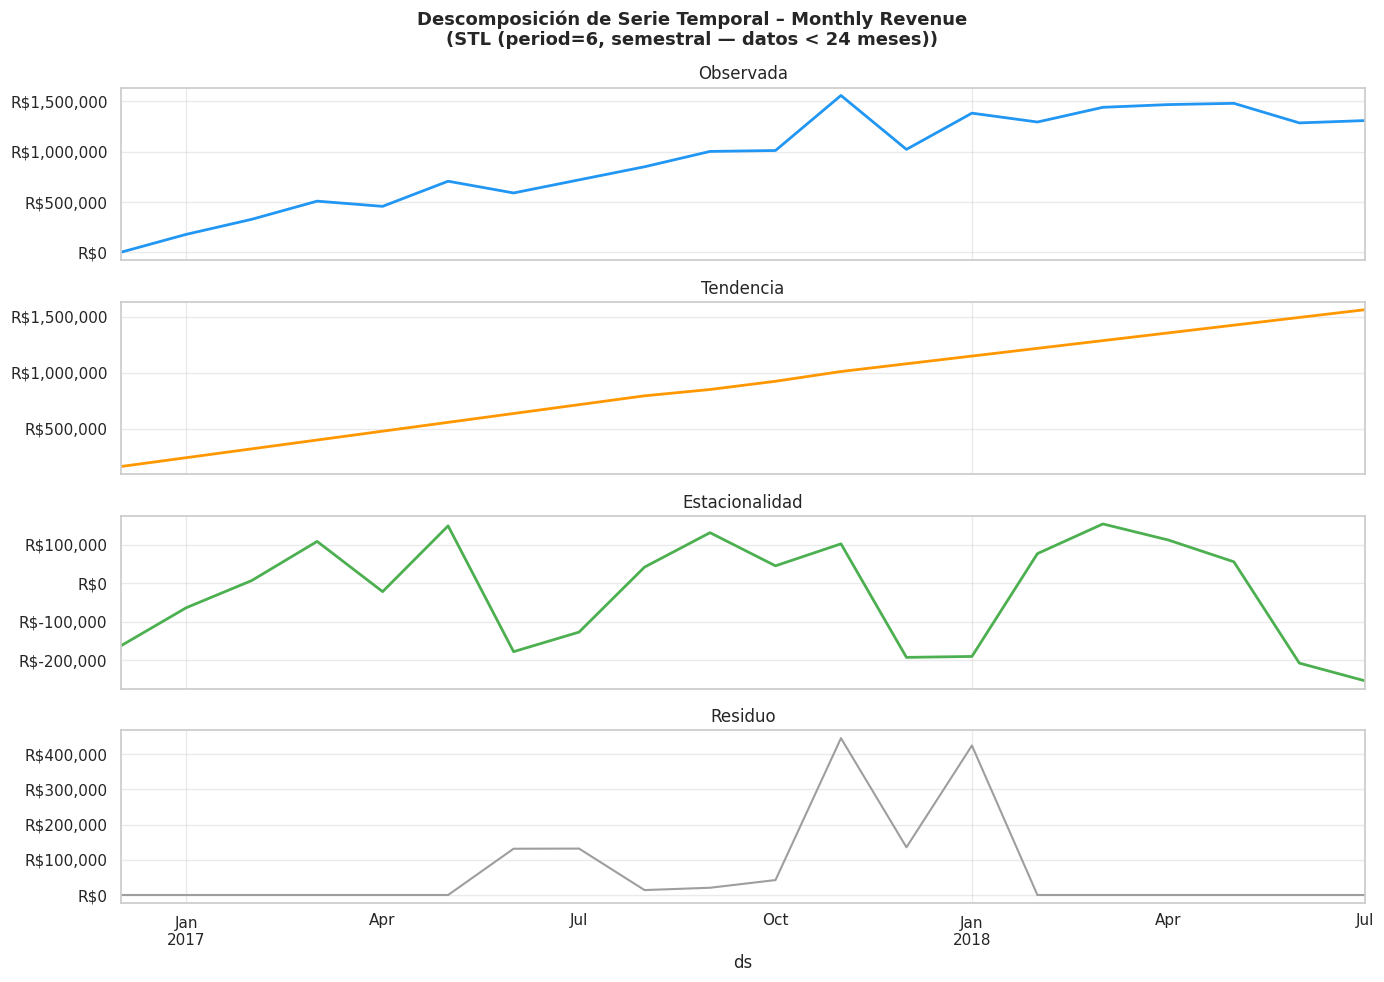

 Gráfico de descomposición guardado


In [ ]:
from statsmodels.tsa.seasonal import STL

ts_revenue = monthly_agg.set_index('ds')['monthly_revenue']
n_obs = len(ts_revenue)
print(f' Observaciones disponibles: {n_obs} meses')

# ─── Elegir método según cantidad de datos disponibles
# seasonal_decompose necesita >= 2*period; STL es más flexible (period mínimo ~7)
if n_obs >= 24:
    # Caso ideal: 2+ años completos → descomposición anual
    decomposition = seasonal_decompose(ts_revenue, model='additive', period=12)
    trend_series    = decomposition.trend
    seasonal_series = decomposition.seasonal
    resid_series    = decomposition.resid
    method_label    = 'seasonal_decompose (period=12)'
elif n_obs >= 14:
    # Fallback: usar STL con period=6 (semestral)
    stl = STL(ts_revenue, period=6, robust=True)
    result = stl.fit()
    trend_series    = result.trend
    seasonal_series = result.seasonal
    resid_series    = result.resid
    method_label    = 'STL (period=6, semestral — datos < 24 meses)'
else:
    raise ValueError(f'Serie demasiado corta ({n_obs} obs). Se necesitan al menos 14 meses.')

print(f' Método utilizado: {method_label}')

# ─── Gráfico de descomposición
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Descomposición de Serie Temporal – Monthly Revenue\n({method_label})',
             fontsize=13, fontweight='bold')

ts_revenue.plot(ax=axes[0], color='#2196F3', linewidth=2)
axes[0].set_title('Observada')

trend_series.plot(ax=axes[1], color='#FF9800', linewidth=2)
axes[1].set_title('Tendencia')

seasonal_series.plot(ax=axes[2], color='#4CAF50', linewidth=2)
axes[2].set_title('Estacionalidad')

resid_series.plot(ax=axes[3], color='#9E9E9E', linewidth=1.5)
axes[3].set_title('Residuo')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x:,.0f}'))
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/decomposition_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico de descomposición guardado')

# 6.4 Test de Estacionariedad - Dickey-Fuller

In [ ]:
def adf_test(series, name='Serie'):
    result = adfuller(series.dropna())
    print(f'\n Test ADF – {name}')
    print(f'   Estadístico: {result[0]:.4f}')
    print(f'   p-value:     {result[1]:.4f}')
    print(f'   Lags usados: {result[2]}')
    for key, val in result[4].items():
        print(f'   Valor crítico ({key}): {val:.4f}')
    if result[1] < 0.05:
        print('    CONCLUSIÓN: La serie ES ESTACIONARIA (rechaza H0)')
    else:
        print('     CONCLUSIÓN: La serie NO ES ESTACIONARIA (no rechaza H0)')
        print('      → Se recomienda diferenciación antes del modelado')

adf_test(monthly_agg['monthly_revenue'], 'Monthly Revenue')
adf_test(monthly_agg['monthly_revenue'].diff().dropna(), 'Monthly Revenue (1ª diferencia)')


 Test ADF – Monthly Revenue
   Estadístico: -1.9516
   p-value:     0.3082
   Lags usados: 8
   Valor crítico (1%): -4.2232
   Valor crítico (5%): -3.1894
   Valor crítico (10%): -2.7298
     CONCLUSIÓN: La serie NO ES ESTACIONARIA (no rechaza H0)
      → Se recomienda diferenciación antes del modelado

 Test ADF – Monthly Revenue (1ª diferencia)
   Estadístico: -8.5966
   p-value:     0.0000
   Lags usados: 0
   Valor crítico (1%): -3.8591
   Valor crítico (5%): -3.0420
   Valor crítico (10%): -2.6609
    CONCLUSIÓN: La serie ES ESTACIONARIA (rechaza H0)


# 6.5 Análisis de Autocorrelación

 Observaciones: 20  →  ACF lags: 12  |  PACF lags: 9


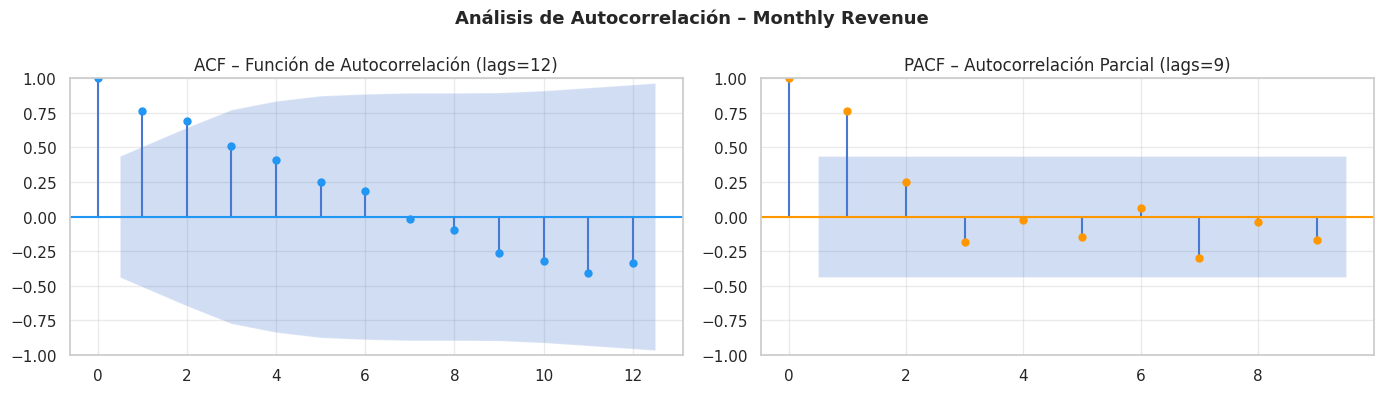

In [ ]:
series = monthly_agg['monthly_revenue'].dropna()
n_obs  = len(series)

# ACF puede usar hasta n-1 lags; PACF está limitado a n//2 - 1
max_lags_acf  = min(12, n_obs - 1)
max_lags_pacf = min(12, n_obs // 2 - 1)

print(f' Observaciones: {n_obs}  →  ACF lags: {max_lags_acf}  |  PACF lags: {max_lags_pacf}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Análisis de Autocorrelación – Monthly Revenue', fontsize=13, fontweight='bold')

plot_acf(series,  lags=max_lags_acf,  ax=axes[0], color='#2196F3')
plot_pacf(series, lags=max_lags_pacf, ax=axes[1], color='#FF9800')

axes[0].set_title(f'ACF – Función de Autocorrelación (lags={max_lags_acf})')
axes[1].set_title(f'PACF – Autocorrelación Parcial (lags={max_lags_pacf})')

for ax in axes:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# 6.6 Análisis por Categoría de Producto

In [ ]:
# Top 15 categorías por revenue
cat_revenue = (
    df_valid
    .groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
cat_revenue.columns = ['categoria', 'revenue_total']
cat_revenue['pct_revenue'] = (cat_revenue['revenue_total'] / cat_revenue['revenue_total'].sum() * 100).round(2)
cat_revenue['cumulative_pct'] = cat_revenue['pct_revenue'].cumsum()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(
    go.Bar(x=cat_revenue['categoria'], y=cat_revenue['revenue_total'],
           name='Revenue Total (BRL)', marker_color='#2196F3'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=cat_revenue['categoria'], y=cat_revenue['cumulative_pct'],
               name='% Acumulado', line=dict(color='#FF5722', width=2),
               mode='lines+markers'),
    secondary_y=True
)
fig.update_layout(
    title=' Diagrama de Pareto – Revenue por Categoría (Top 15)',
    xaxis_tickangle=-35, height=450
)
fig.update_yaxes(title_text='Revenue Total (BRL)', secondary_y=False)
fig.update_yaxes(title_text='% Acumulado', secondary_y=True)
fig.show()

print('\n Validación H3 – Pareto por categoría:')
pareto_80 = cat_revenue[cat_revenue['cumulative_pct'] <= 80]
print(f'   El {len(pareto_80)} de las top categorías generan ~80% del revenue')
print(cat_revenue[['categoria', 'pct_revenue', 'cumulative_pct']].head(8).to_string(index=False))


 Validación H3 – Pareto por categoría:
   El 9 de las top categorías generan ~80% del revenue
            categoria  pct_revenue  cumulative_pct
       bed_bath_table        11.29           11.29
        health_beauty        10.64           21.93
computers_accessories        10.23           32.16
      furniture_decor         9.22           41.38
        watches_gifts         9.09           50.47
       sports_leisure         8.89           59.36
           housewares         7.02           66.38
                 auto         5.47           71.85


# 6.7 Análisis de Outliers

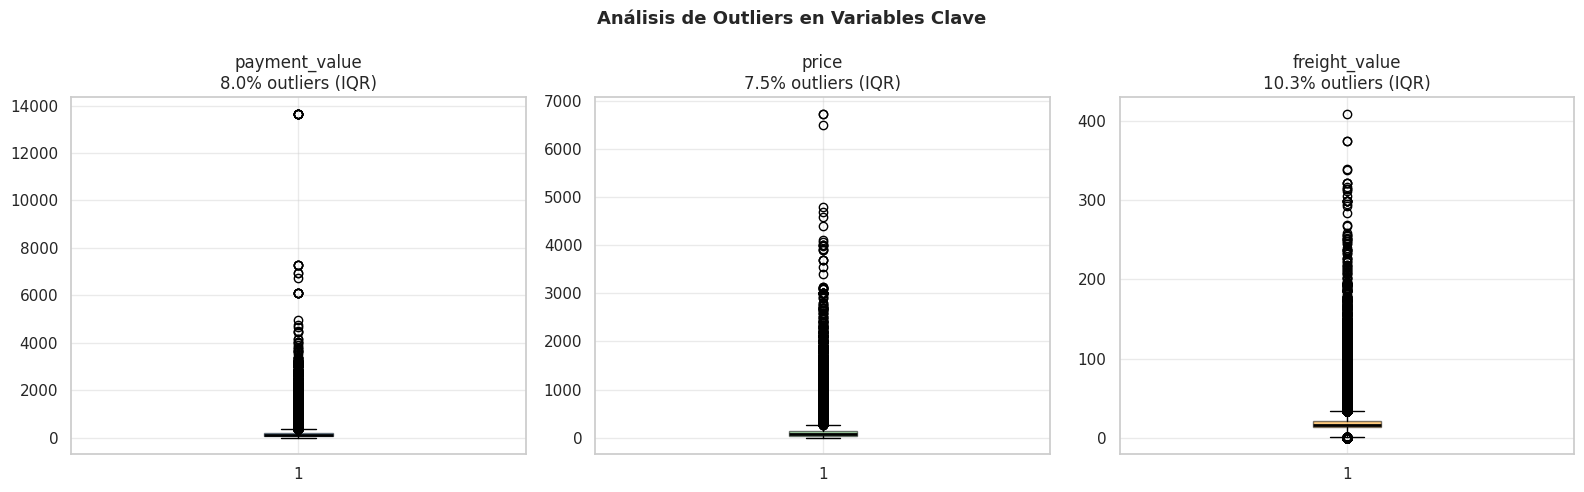


 Resumen estadístico de outliers:
   payment_value       : 9,285 outliers (8.0%) | Max: R$13,664 | Mediana: R$108
   price               : 8,634 outliers (7.5%) | Max: R$6,735 | Mediana: R$75
   freight_value       : 11,876 outliers (10.3%) | Max: R$410 | Mediana: R$16


In [ ]:
# Boxplot de payment_value
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Outliers en Variables Clave', fontsize=13, fontweight='bold')

vars_outlier = ['payment_value', 'price', 'freight_value']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, var, color in zip(axes, vars_outlier, colors):
    data = df_valid[var].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers_pct = (data > upper).mean() * 100

    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{var}\n{outliers_pct:.1f}% outliers (IQR)')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Resumen IQR
print('\n Resumen estadístico de outliers:')
for var in vars_outlier:
    data = df_valid[var].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = (data > q3 + 1.5*iqr).sum()
    print(f'   {var:20s}: {n_outliers:,} outliers ({n_outliers/len(data)*100:.1f}%)'
          f' | Max: R${data.max():,.0f} | Mediana: R${data.median():,.0f}')

# 6.8 Mapa de Correlaciones

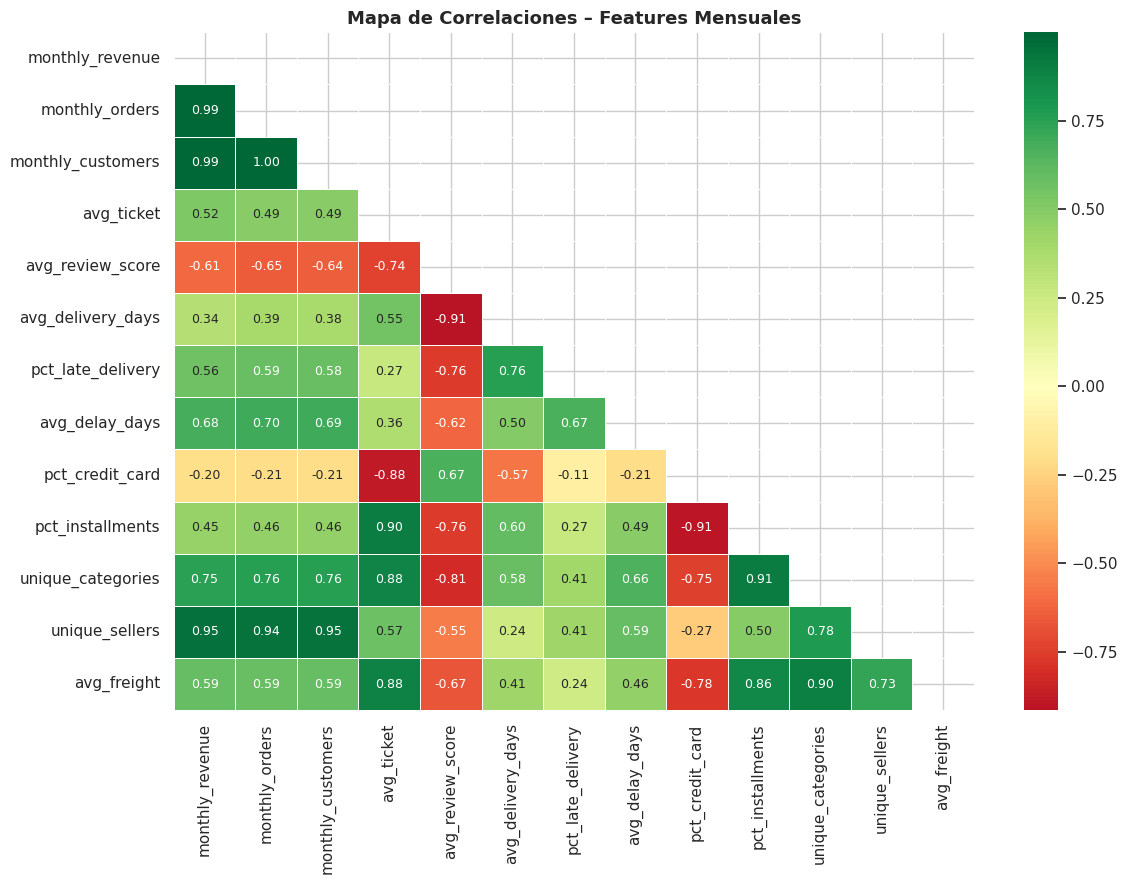


 Correlaciones con monthly_revenue (ordenadas):
   monthly_customers        : +0.991  ███████████████████
   monthly_orders           : +0.991  ███████████████████
   unique_sellers           : +0.951  ███████████████████
   unique_categories        : +0.751  ███████████████
   avg_delay_days           : +0.681  █████████████
   avg_review_score         : -0.614  ████████████
   avg_freight              : +0.594  ███████████
   pct_late_delivery        : +0.561  ███████████
   avg_ticket               : +0.518  ██████████
   pct_installments         : +0.450  █████████
   avg_delivery_days        : +0.340  ██████
   pct_credit_card          : -0.197  ███


In [ ]:
corr_features = [
    'monthly_revenue', 'monthly_orders', 'monthly_customers', 'avg_ticket',
    'avg_review_score', 'avg_delivery_days', 'pct_late_delivery',
    'avg_delay_days', 'pct_credit_card', 'pct_installments',
    'unique_categories', 'unique_sellers', 'avg_freight'
]

corr_matrix = monthly_agg[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, annot_kws={'size': 9}
)
ax.set_title('Mapa de Correlaciones – Features Mensuales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones con target
print('\n Correlaciones con monthly_revenue (ordenadas):')
top_corr = corr_matrix['monthly_revenue'].drop('monthly_revenue').sort_values(key=abs, ascending=False)
for feat, val in top_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'   {feat:25s}: {sign}{abs(val):.3f}  {bar}')

# 7. Métricas de Negocio (Baseline)

In [ ]:
print(' MÉTRICAS DE NEGOCIO – BASELINE')
print('='*60)

# ── Revenue total
total_revenue     = df_valid['payment_value'].sum()
avg_monthly_rev   = monthly_agg['monthly_revenue'].mean()
median_monthly    = monthly_agg['monthly_revenue'].median()
max_monthly       = monthly_agg['monthly_revenue'].max()
min_monthly       = monthly_agg['monthly_revenue'].min()

# ── Satisfacción
avg_review        = df_valid['review_score'].mean()
pct_5star         = (df_valid['review_score'] == 5).mean() * 100
pct_1star         = (df_valid['review_score'] == 1).mean() * 100

# ── Entrega
avg_delivery      = df_valid['delivery_days_actual'].mean()
pct_on_time       = (df_valid['is_late_delivery'] == 0).mean() * 100
avg_delay         = df_valid[df_valid['delivery_delay_days'] > 0]['delivery_delay_days'].mean()

# ── Clientes
total_customers   = df_valid['customer_unique_id'].nunique()
repeat_customers  = (df_valid.groupby('customer_unique_id')['order_id'].nunique() > 1).mean() * 100

# ── Cancelaciones
cancel_rate       = (df_master['order_status'] == 'canceled').mean() * 100

metrics_dict = {
    ' Revenue Total (BRL)':          f'R$ {total_revenue:,.2f}',
    ' Revenue Promedio Mensual':      f'R$ {avg_monthly_rev:,.2f}',
    ' Revenue Mediana Mensual':       f'R$ {median_monthly:,.2f}',
    ' Revenue Máximo Mensual':        f'R$ {max_monthly:,.2f}',
    ' Revenue Mínimo Mensual':        f'R$ {min_monthly:,.2f}',
    ' Review Score Promedio':          f'{avg_review:.3f} / 5.0',
    ' % Calificaciones 5★':            f'{pct_5star:.1f}%',
    ' % Calificaciones 1★':           f'{pct_1star:.1f}%',
    ' Tiempo Entrega Promedio':       f'{avg_delivery:.1f} días',
    ' % Entregas a Tiempo':           f'{pct_on_time:.1f}%',
    '  Retraso Promedio (tardíos)':   f'{avg_delay:.1f} días',
    ' Total Clientes Únicos':         f'{total_customers:,}',
    ' % Clientes Recurrentes':        f'{repeat_customers:.2f}%',
    ' Tasa de Cancelación':           f'{cancel_rate:.2f}%',
}

for k, v in metrics_dict.items():
    print(f'   {k:40s} {v}')

 MÉTRICAS DE NEGOCIO – BASELINE
    Revenue Total (BRL)                     R$ 19,881,945.07
    Revenue Promedio Mensual                R$ 930,420.72
    Revenue Mediana Mensual                 R$ 1,007,873.25
    Revenue Máximo Mensual                  R$ 1,559,739.87
    Revenue Mínimo Mensual                  R$ 19.62
    Review Score Promedio                   4.081 / 5.0
    % Calificaciones 5★                     57.1%
    % Calificaciones 1★                     11.3%
    Tiempo Entrega Promedio                 12.0 días
    % Entregas a Tiempo                     92.7%
     Retraso Promedio (tardíos)             10.0 días
    Total Clientes Únicos                   93,357
    % Clientes Recurrentes                  3.00%
    Tasa de Cancelación                     0.63%


## 8. Baseline del Modelo Predictivo

### 8.1 Métodos Naive de Referencia

In [ ]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_metric(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Usar últimos 3 meses como test
n_test = 3
train = monthly_agg.iloc[:-n_test].copy()
test  = monthly_agg.iloc[-n_test:].copy()

y_test = test['monthly_revenue'].values

# ── Modelo 1: Naive (último valor observado)
naive_pred    = np.full(n_test, train['monthly_revenue'].iloc[-1])

# ── Modelo 2: Promedio móvil 3 meses
ma3_pred      = np.full(n_test, train['monthly_revenue'].tail(3).mean())

# ── Modelo 3: Seasonal Naive (mismo mes año anterior)
seasonal_pred = []
for i in range(n_test):
    idx = len(train) - 12 + i
    val = train['monthly_revenue'].iloc[idx] if idx >= 0 else train['monthly_revenue'].mean()
    seasonal_pred.append(val)
seasonal_pred = np.array(seasonal_pred)

# ── Modelo 4: Tendencia Lineal
from numpy.polynomial import polynomial as P
x_train = np.arange(len(train))
x_test  = np.arange(len(train), len(train) + n_test)
coefs   = np.polyfit(x_train, train['monthly_revenue'], 1)
linear_pred = np.polyval(coefs, x_test)

# ── Tabla de resultados
baseline_results = pd.DataFrame([
    {'Modelo': 'Naive (último valor)',
     'RMSE':  rmse(y_test, naive_pred),
     'MAE':   mae_metric(y_test, naive_pred),
     'MAPE':  mape(y_test, naive_pred)},
    {'Modelo': 'Media Móvil 3M',
     'RMSE':  rmse(y_test, ma3_pred),
     'MAE':   mae_metric(y_test, ma3_pred),
     'MAPE':  mape(y_test, ma3_pred)},
    {'Modelo': 'Seasonal Naive (año anterior)',
     'RMSE':  rmse(y_test, seasonal_pred),
     'MAE':   mae_metric(y_test, seasonal_pred),
     'MAPE':  mape(y_test, seasonal_pred)},
    {'Modelo': 'Tendencia Lineal',
     'RMSE':  rmse(y_test, linear_pred),
     'MAE':   mae_metric(y_test, linear_pred),
     'MAPE':  mape(y_test, linear_pred)},
])

print(' RESULTADOS DE BASELINE (últimos 3 meses como test)')
print('='*65)
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print(f'\n   Objetivo del modelo final: MAPE < 10%')
best_model = baseline_results.loc[baseline_results['MAPE'].idxmin()]
print(f'   Mejor baseline actual: {best_model["Modelo"]} (MAPE: {best_model["MAPE"]:.2f}%)')

 RESULTADOS DE BASELINE (últimos 3 meses como test)
                       Modelo       RMSE        MAE  MAPE
         Naive (último valor) 139,874.73 117,930.31  9.05
               Media Móvil 3M  96,803.98  95,645.99  7.12
Seasonal Naive (año anterior) 691,070.88 686,897.28 50.47
             Tendencia Lineal 423,893.54 395,532.86 29.87

   Objetivo del modelo final: MAPE < 10%
   Mejor baseline actual: Media Móvil 3M (MAPE: 7.12%)


# 8.2 Visualización del Baseline vs Real

In [ ]:
fig = go.Figure()

# Serie histórica
fig.add_trace(go.Scatter(
    x=train['ds'], y=train['monthly_revenue'],
    name='Histórico', line=dict(color='#2196F3', width=2)
))

# Valores reales del test
fig.add_trace(go.Scatter(
    x=test['ds'], y=test['monthly_revenue'],
    name='Real (test)', line=dict(color='black', width=2.5, dash='dash'),
    mode='lines+markers', marker=dict(size=8)
))

# Predicciones baseline
colors_pred = ['#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
preds = [naive_pred, ma3_pred, seasonal_pred, linear_pred]
nombres = ['Naive', 'MA-3M', 'Seasonal Naive', 'Tendencia Lineal']

for pred, name, color in zip(preds, nombres, colors_pred):
    fig.add_trace(go.Scatter(
        x=test['ds'], y=pred,
        name=name, line=dict(color=color, width=2, dash='dot'),
        mode='lines+markers'
    ))

fig.update_layout(
    title=' Comparación de Modelos Baseline vs Real',
    xaxis_title='Fecha', yaxis_title='Revenue Mensual (BRL)',
    height=450, hovermode='x unified'
)
fig.show()

# 9. Validación de Hipótesis

In [ ]:
print(' VALIDACIÓN DE HIPÓTESIS')
print('='*70)

# H1 – Estacionalidad
monthly_avg_by_month = monthly_agg.groupby('month')['monthly_revenue'].mean()
max_month = monthly_avg_by_month.idxmax()
min_month = monthly_avg_by_month.idxmin()
month_names = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
print(f'\n[H1] Estacionalidad:')
print(f'     Mes con mayor revenue promedio: {month_names[max_month]} (mes {max_month})')
print(f'     Mes con menor revenue promedio: {month_names[min_month]} (mes {min_month})')
q4_avg   = monthly_agg[monthly_agg['is_q4']==1]['monthly_revenue'].mean()
rest_avg = monthly_agg[monthly_agg['is_q4']==0]['monthly_revenue'].mean()
print(f'     Revenue promedio Q4 vs resto: R${q4_avg:,.0f} vs R${rest_avg:,.0f} '
      f'({(q4_avg/rest_avg-1)*100:+.1f}%)')

# H2 – Correlación órdenes vs revenue
from scipy.stats import pearsonr
corr_h2, p_h2 = pearsonr(monthly_agg['monthly_orders'], monthly_agg['monthly_revenue'])
print(f'\n[H2] Correlación órdenes vs revenue:')
print(f'     Pearson r = {corr_h2:.4f}, p-value = {p_h2:.4f}')
print(f'     {" CONFIRMADA" if corr_h2 > 0.8 else " PARCIALMENTE CONFIRMADA"}')

# H4 – Entrega vs satisfacción
df_valid_h4 = df_valid[['delivery_delay_days', 'review_score']].dropna()
corr_h4, p_h4 = pearsonr(df_valid_h4['delivery_delay_days'], df_valid_h4['review_score'])
print(f'\n[H4] Correlación retraso entrega vs review score:')
print(f'     Pearson r = {corr_h4:.4f}, p-value = {p_h4:.4f}')
print(f'     {" CONFIRMADA (relación negativa)" if corr_h4 < -0.05 else " Relación débil"}')

# H5 – Tasa de recompra
print(f'\n[H5] Tasa de clientes recurrentes: {repeat_customers:.2f}%')
print(f'     Oportunidad de mejora: la tasa de recompra es muy baja, '
      f'lo que indica que la retención es el principal desafío.')

 VALIDACIÓN DE HIPÓTESIS

[H1] Estacionalidad:
     Mes con mayor revenue promedio: Nov (mes 11)
     Mes con menor revenue promedio: Dic (mes 12)
     Revenue promedio Q4 vs resto: R$898,904 vs R$938,300 (-4.2%)

[H2] Correlación órdenes vs revenue:
     Pearson r = 0.9907, p-value = 0.0000
      CONFIRMADA

[H4] Correlación retraso entrega vs review score:
     Pearson r = -0.2285, p-value = 0.0000
      CONFIRMADA (relación negativa)

[H5] Tasa de clientes recurrentes: 3.00%
     Oportunidad de mejora: la tasa de recompra es muy baja, lo que indica que la retención es el principal desafío.
